# Optimization

#### Imports

In [1]:
%reload_ext autoreload
%autoreload 2

In [6]:
import sys
import os

# Add the parent directory (or another appropriate path) to sys.path so Python can find Exclusion_functions
notebook_dir = os.path.dirname(os.path.abspath('04_Optimization.ipynb'))
parent_dir = os.path.abspath(os.path.join(notebook_dir, '..', '..', '..'))
function_dir = os.path.abspath(os.path.join(parent_dir, 'Function_Files'))
if function_dir not in sys.path:
    sys.path.append(function_dir)

import pandas as pd
import polars as pl
import Exclusion_functions as ef
import Optimization_functions as of
import Final_report_functions as frf
import datetime
import numpy as np

In [7]:
CATEGORY = "Cups"
today = datetime.datetime.now().strftime('%m.%d.%Y')
ip_path = f"{parent_dir}\\Data\\"
ip_path_cat = f"{parent_dir}\\Data\\{CATEGORY}\\"
OP_PATH = f"{parent_dir}\\Data\\{CATEGORY}\\Output\\"

In [8]:
im_final = pd.read_csv(f"{OP_PATH}{CATEGORY}_matches.csv")
transactions = pd.read_csv(f"{OP_PATH}Cups Sales Data L6M Feb-Jul - Cleaned.csv")

C:\Users\zwayne\AppData\Local\Temp\ipykernel_19064\988896953.py:2: DtypeWarning: Columns (17) have mixed types. Specify dtype option on import or set low_memory=False.
  transactions = pd.read_csv(f"{OP_PATH}Cups Sales Data L6M Feb-Jul - Cleaned.csv")


#### Get Exclusions

In [6]:
# Merge the datasets and handle missing columns in one step.
# The merge operation automatically handles the join, so you can focus on the aggregation.
# Using a left join ensures all transactions are kept.
transactions_merged = transactions.merge(
    im_final[["Entity--Item", "Matches"]],
    on="Entity--Item",
    how="left"
)

# Define the aggregation dictionary.
# This approach is more concise and easier to read.
# Use a custom lambda function for the "first non-null" logic.
# The .first() method is also a great alternative for this purpose.
agg_dict = {
    "Qty": "sum",
    "Net Cost": "sum",
    "Gross Cost": "sum",
    "Matches": "first",
    "VGN": "first",
    "Customer Class": "first",
    "Price Group Name": "first",
    "Case Pack": "mean",
}

# Group and aggregate in a single step.
# .first() is a built-in aggregation method that returns the first non-null value,
# which is more efficient than a custom function.
# Ensure "Case Pack" is numeric before aggregation
transactions_merged["Case Pack"] = pd.to_numeric(transactions_merged["Case Pack"], errors="coerce")


transactions_grouped_by_item_customer = (
    transactions_merged
    .groupby(["Entity--Item", "Customer Code"], dropna=False)
    .agg(agg_dict)
    .rename(columns={
        "Qty": "Total_Qty",
        "Net Cost": "Total_Net_Cogs",
        "Gross Cost": "Total_Gross_Cost",
        "Price Group Name": "Customer_Name",
    })
    .reset_index()
)

In [7]:
vendor_exclusions = pd.read_excel(f"{ip_path}Customer and Vendor Exclusions.xlsx", sheet_name="VGN Table list", skiprows=2)
vendor_exclusions = set(vendor_exclusions[vendor_exclusions['Nonaddressable'] == 'X']['VGN'].tolist())
vendor_exclusions = vendor_exclusions.union(['Direct Link','Carryout Bags, Inc.'])
vendor_exclusions = im_final[im_final['VGN'].isin(vendor_exclusions)]['Entity--Item'].unique().tolist()
print(f"Found {len(vendor_exclusions)} unqiue SKUS bought by excluded vendors")

Found 263 unqiue SKUS bought by excluded vendors


In [8]:
redi = ef.get_skus_to_redi(transactions_grouped_by_item_customer)
redi_skus = redi['Entity--Item'].unique().tolist()

Found 893 unique SKUs serving redi customers


In [9]:
customer_exclusions = pd.read_excel(f"{ip_path}Customer and Vendor Exclusions.xlsx", sheet_name="Customer Table list", skiprows=2)
customer_exclusions = set(customer_exclusions[customer_exclusions['Nonaddressable'] == 'X']['Customer Name'].tolist())
get_skus_to_excl_cust = ef.get_skus_to_excl_cust(transactions_grouped_by_item_customer, customer_exclusions)
customer_exclusions_skus = get_skus_to_excl_cust['Entity--Item'].unique().tolist()

Found 1387 unique SKUs bought by excluded customers


In [10]:
must_keep_ids = list(set(vendor_exclusions + redi_skus + customer_exclusions_skus)); len(must_keep_ids)

1820

In [11]:
rebates = pd.read_excel(f"{ip_path}\\Rebates.xlsx")
cost_diff_df = of.get_cost_diff_df(im_final, transactions, rebates)

#### Loop through optimization

In [12]:
results = of.solve_swap_optimization_looped(im_final, cost_diff_df, must_keep_ids)

--- Initializing Looped Optimization Problem ---
Starting optimization loop. Initial max suppliers: 217

--- Solving for Max Suppliers <= 217 ---
--- Initializing Swap Optimization Problem ---
--- Optimization Results ---
Status: Optimal
Total yearly cost savings: $4,677,669.14
Number of swaps: 1747
Active suppliers: 178

--- Solving for Max Suppliers <= 206 ---
--- Initializing Swap Optimization Problem ---
--- Optimization Results ---
Status: Optimal
Total yearly cost savings: $4,677,669.14
Number of swaps: 1747
Active suppliers: 178

--- Solving for Max Suppliers <= 195 ---
--- Initializing Swap Optimization Problem ---
--- Optimization Results ---
Status: Optimal
Total yearly cost savings: $4,677,669.14
Number of swaps: 1747
Active suppliers: 178

--- Solving for Max Suppliers <= 185 ---
--- Initializing Swap Optimization Problem ---
--- Optimization Results ---
Status: Optimal
Total yearly cost savings: $4,677,669.14
Number of swaps: 1747
Active suppliers: 178

--- Solving for Max

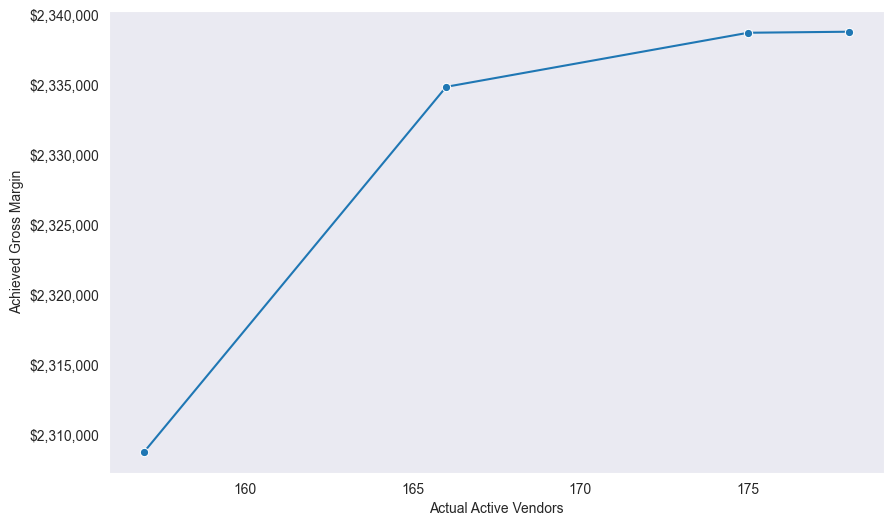

In [13]:
# graph Actual_Active_Suppliers vs Achieved_Gross_Margin
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.lineplot(data=results, x='Actual_Active_Suppliers', y='Achieved_Cost_Savings', marker='o')
plt.xlabel('Actual Active Vendors')
plt.ylabel('Achieved Gross Margin')
plt.gca().yaxis.set_major_formatter('${x:,.0f}')
plt.grid()
plt.show()


#### Run best optimization and update df

In [14]:
max_suppliers_limit = 192
# max_gross_margin or min_active_suppliers
results = of.solve_swap_optimization(im_final, cost_diff_df, must_keep_ids, max_suppliers = max_suppliers_limit)

--- Initializing Swap Optimization Problem ---
--- Optimization Results ---
Status: Optimal
Total yearly cost savings: $4,677,669.14
Number of swaps: 1747
Active suppliers: 178


In [15]:
updated_df = of.analyze_swap_results(im_final, results)

In [16]:
print("Current Number of SKUs:", len(updated_df['Entity--Item'].unique()))
print("New Number of SKUs:", len(updated_df[updated_df['Final_Volume'] > 0.1]['Entity--Item'].unique()))
print("\n")
print("Volume the Same? ", updated_df['Original_Volume'].sum() == updated_df['Final_Volume'].sum())
print("\n")
print("Current Vendors:", len(updated_df['Original_Supplier'].unique()))
print("New Vendors:", len(updated_df['New_Supplier'].unique()))
print("\n")

print(f"GM Difference: ${(updated_df['Savings_From_Swapping_To']).sum() * 2:,.2f}")

Current Number of SKUs: 4481
New Number of SKUs: 2734


Volume the Same?  True


Current Vendors: 218
New Vendors: 178


GM Difference: $4,677,669.14


In [17]:
im_final_with_feedback = pd.read_csv(f"{OP_PATH}{CATEGORY}_feedback_df.csv")

In [18]:
frf.create_enhanced_sku_report(updated_df, im_final_with_feedback, transactions_grouped_by_item_customer,  f"{OP_PATH}{CATEGORY}_Final_Report_{today}.xlsx" , customer_exclusions = get_skus_to_excl_cust['Customer Code'].unique().tolist(), redi_customers= redi['Customer Code'].unique().tolist())

--- Starting to generate Enhanced SKU Report: C:\Users\MGadupudi\PycharmProjects\ImperialDadeCategoryManagement\Data\Cups\Output\Cups_Final_Report_10.08.2025.xlsx ---

--- Processing Sheet: Suggested Swaps ---

--- Processing Sheet: Vendor Performance Summary ---

--- Processing Sheet: Customer Performance Summary ---
--- Successfully created Enhanced SKU Report: C:\Users\MGadupudi\PycharmProjects\ImperialDadeCategoryManagement\Data\Cups\Output\Cups_Final_Report_10.08.2025.xlsx ---


True

In [478]:
#im_final.to_excel(f"{OP_PATH}{CATEGORY}_Full_{today}.xlsx", index=False)

# Optimization Feedback

In [20]:
# drop_list_df, suggested_swaps_df = f.read_and_process_feedback_excel( f"{OP_PATH}{CATEGORY}_drop_list_{today}.xlsx")
suggested_swaps_df = frf.read_and_process_feedback_excel( f"{OP_PATH}Cups_Final_Report_10.08.2025.xlsx")

--- Reading feedback from Excel file: C:\Users\MGadupudi\PycharmProjects\ImperialDadeCategoryManagement\Data\Cups\Output\Cups_Final_Report_10.08.2025.xlsx ---
Processing sheet: Suggested Swaps...
Successfully extracted data from 'Suggested Swaps'. Found 1747 rows.


In [21]:
im_final = frf.incorporate_swaps_feedback(im_final, suggested_swaps_df)

## Go back and rerun optimization